In [2]:
## Лабораторная работа номер 2

## Выполнил: Косолапов Павел Евгеньевич
## Группа: 2303
## мой номер 230311
## Вариант - 7

In [3]:
## Устанавливаем необходимые библиотеки

In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn requests

Note: you may need to restart the kernel to use updated packages.


In [5]:
## Импортируем необходимые библиотеки

In [9]:

import io
import os
import re
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, Ellipse, Polygon, Arc
import seaborn as sns

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
sns.set_theme(style="whitegrid", font="DejaVu Sans")

In [10]:
## Извлекаем необходимые данные из архива

In [11]:
from urllib.request import urlretrieve

LOCAL_ARCHIVE = Path("MC2 Data.zip")

def ensure_main_archive(local_candidat=None, target_path="MC2 Data.zip"):
    candidat = Path(local_candidat)
    if candidat.exists():
        return candidat

def load_hvac_data(main_archive_path):
    main_archive_path = Path(main_archive_path)
    with zipfile.ZipFile(main_archive_path) as main_zip:
        nested_name = next(
            name for name in main_zip.namelist()
            if name.endswith("MCBuildingProxSensorData.zip")
        )
        nested_bytes = io.BytesIO(main_zip.read(nested_name))

        with zipfile.ZipFile(nested_bytes) as nested_zip:
            csv_name = next(
                name for name in nested_zip.namelist()
                if name.endswith("csv/bldg-MC2.csv")
            )
            with nested_zip.open(csv_name) as csv_file:
                data = pd.read_csv(csv_file)
    return data

archive_path = ensure_main_archive(
    local_candidat=LOCAL_ARCHIVE
)

df = load_hvac_data(archive_path)
df.head()

,Date/Time,Drybulb Temperature,Water Heater Tank Temperature,Water Heater Gas Rate,Supply Side Inlet Mass Flow Rate,Supply Side Inlet Temperature,Supply Side Outlet Temperature,HVAC Electric Demand Power,Total Electric Demand Power,Loop Temp Schedule,...,F_3_Z_10 SUPPLY INLET Mass Flow Rate,F_3_Z_11A RETURN OUTLET CO2 Concentration,F_3_Z_11A SUPPLY INLET Temperature,F_3_Z_11A SUPPLY INLET Mass Flow Rate,F_3_Z_11B RETURN OUTLET CO2 Concentration,F_3_Z_11B SUPPLY INLET Temperature,F_3_Z_11B SUPPLY INLET Mass Flow Rate,F_3_Z_11C RETURN OUTLET CO2 Concentration,F_3_Z_11C SUPPLY INLET Temperature,F_3_Z_11C SUPPLY INLET Mass Flow Rate
0,2016-05-31 00:00:00,22.80,59.3726,0.0,0.3179,57.9886,59.3726,13405.3319,83922.6009,60.0,...,0.0278,492.0690,12.8008,0.0487,484.1789,12.8008,0.1612,489.7175,12.8008,0.1188
1,2016-05-31 00:05:00,22.75,59.3362,0.0,0.3179,58.6947,59.3362,13212.0457,74934.1112,60.0,...,0.0278,491.8141,12.8008,0.0487,483.6176,12.8008,0.1618,489.4151,12.8008,0.1193
2,2016-05-31 00:10:00,22.70,59.3279,0.0,0.3179,59.2583,59.3279,13150.3329,74872.3984,60.0,...,0.0278,491.5502,12.8000,0.0487,483.0598,12.8000,0.1553,489.0991,12.8000,0.1196
3,2016-05-31 00:15:00,22.65,59.3338,0.0,0.3179,59.3628,59.3338,13129.6643,77222.0684,60.0,...,0.0278,491.2777,12.8007,0.0487,482.5124,12.8007,0.1561,488.7704,12.8007,0.1200
4,2016-05-31 00:20:00,22.60,59.3420,0.0,0.3179,59.3851,59.3420,13117.4059,77209.8099,60.0,...,0.0278,490.9968,12.8004,0.0487,481.9631,12.8004,0.1567,488.4300,12.8004,0.1203


In [12]:
## Выделяем столбцы, которые относятся к моему варианту

In [13]:
STUDENT_NUMBER = 230311
VARIANT = STUDENT_NUMBER % 8
ZONE_PATTERN = "F_3_Z_8"

df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["date"] = df["Date/Time"].dt.date
df["weekday"] = df["Date/Time"].dt.day_name()

zone_cols = [col for col in df.columns if ZONE_PATTERN in col]
print("Вариант:", VARIANT)
print("Контролируемая зона:", ZONE_PATTERN)
print("Количество параметров зоны:", len(zone_cols))
for col in zone_cols:
    print("-", col)

zone_df = df[["Date/Time", "date", "weekday"] + zone_cols].copy()

Вариант: 7
Контролируемая зона: F_3_Z_8
Количество параметров зоны: 10
-  F_3_Z_8: Lights Power
-  F_3_Z_8: Equipment Power
-  F_3_Z_8: Thermostat Temp
-  F_3_Z_8: Thermostat Heating Setpoint
-  F_3_Z_8: Thermostat Cooling Setpoint
-  F_3_Z_8 VAV REHEAT Damper Position
-  F_3_Z_8 REHEAT COIL Power
-  F_3_Z_8 RETURN OUTLET CO2 Concentration
-  F_3_Z_8 SUPPLY INLET Temperature
-  F_3_Z_8 SUPPLY INLET Mass Flow Rate


In [14]:
## Производим обзор данных

In [15]:
print("Размер датасета:", df.shape)
print("Период наблюдения:", df["Date/Time"].min(), "—", df["Date/Time"].max())
print("Количество уникальных дней:", df["date"].nunique())
print("\nЧисло записей по дням:")
display(df.groupby("date").size().to_frame("rows_per_day"))

print("\nПропуски по параметрам выбранной зоны:")
display(zone_df[zone_cols].isna().sum().to_frame("missing_values"))

display(zone_df[zone_cols].describe().T)

Размер датасета: (4032, 418)
Период наблюдения: 2016-05-31 00:00:00 — 2016-06-13 23:55:00
Количество уникальных дней: 14

Число записей по дням:


,rows_per_day
date,
2016-05-31,288
2016-06-01,288
2016-06-02,288
2016-06-03,288
2016-06-04,288
2016-06-05,288
2016-06-06,288
2016-06-07,288
2016-06-08,288



Пропуски по параметрам выбранной зоны:


,missing_values
F_3_Z_8: Lights Power,0
F_3_Z_8: Equipment Power,0
F_3_Z_8: Thermostat Temp,0
F_3_Z_8: Thermostat Heating Setpoint,0
F_3_Z_8: Thermostat Cooling Setpoint,0
F_3_Z_8 VAV REHEAT Damper Position,0
F_3_Z_8 REHEAT COIL Power,0
F_3_Z_8 RETURN OUTLET CO2 Concentration,0
F_3_Z_8 SUPPLY INLET Temperature,0
F_3_Z_8 SUPPLY INLET Mass Flow Rate,0


,count,mean,std,min,25%,50%,75%,max
F_3_Z_8: Lights Power,4032.0,382.896577,559.264492,0.0000,0.00000,0.00000,1199.564100,1199.5641
F_3_Z_8: Equipment Power,4032.0,382.361052,313.188071,167.9390,167.93900,167.93900,839.694800,839.6948
F_3_Z_8: Thermostat Temp,4032.0,24.265656,2.263242,18.3242,24.00010,24.00110,24.001600,32.2245
F_3_Z_8: Thermostat Heating Setpoint,4032.0,21.772634,4.224116,12.6000,21.00000,21.00000,24.000000,32.2200
F_3_Z_8: Thermostat Cooling Setpoint,4032.0,24.875164,3.419606,15.5600,24.00000,24.00000,25.875000,35.2000
F_3_Z_8 VAV REHEAT Damper Position,4032.0,0.605345,0.357680,0.2000,0.20000,0.54485,1.000000,1.0000
F_3_Z_8 REHEAT COIL Power,4032.0,1694.379812,2180.469786,0.0000,0.00000,0.00000,4222.009550,12087.3651
F_3_Z_8 RETURN OUTLET CO2 Concentration,4032.0,597.874086,239.041545,401.4080,421.00055,494.87950,686.973925,1448.3661
F_3_Z_8 SUPPLY INLET Temperature,4032.0,16.995249,5.796048,12.2806,12.80020,12.80190,21.618925,40.0413
F_3_Z_8 SUPPLY INLET Mass Flow Rate,4032.0,0.301222,0.175148,0.0988,0.09880,0.27060,0.493900,0.4939


In [16]:
## Из вывода можно видеть что:
##    - данные покрывают ровно 14 суток.
##    - пропусков по параметрам нет.
##    - признаким находятся в совершенно разных диапозонах, следовательно нужно нормализация, иначе лица Чернова будут сильно искажены.

In [17]:
## Так как по условию пиктограммы должны представлять 1 день, то преобразуем исходные 5-ти минутные ряды в суточные характеристики.

In [18]:
daily_mean = zone_df.groupby("date")[zone_cols].mean()
daily_std = zone_df.groupby("date")[zone_cols].std()
daily_min = zone_df.groupby("date")[zone_cols].min()
daily_max = zone_df.groupby("date")[zone_cols].max()

display(daily_mean.round(2))

,F_3_Z_8: Lights Power,F_3_Z_8: Equipment Power,F_3_Z_8: Thermostat Temp,F_3_Z_8: Thermostat Heating Setpoint,F_3_Z_8: Thermostat Cooling Setpoint,F_3_Z_8 VAV REHEAT Damper Position,F_3_Z_8 REHEAT COIL Power,F_3_Z_8 RETURN OUTLET CO2 Concentration,F_3_Z_8 SUPPLY INLET Temperature,F_3_Z_8 SUPPLY INLET Mass Flow Rate
date,,,,,,,,,,
2016-05-31,503.98,450.17,23.51,19.25,24.90,0.33,0.00,560.93,12.80,0.16
2016-06-01,508.15,452.50,23.57,19.25,24.90,0.34,0.00,572.22,12.80,0.17
2016-06-02,495.65,445.50,23.72,19.25,24.90,0.38,0.00,570.34,12.80,0.19
2016-06-03,474.83,433.84,23.80,20.42,24.68,0.55,1083.01,564.29,14.95,0.27
2016-06-04,0.00,167.94,24.00,24.00,24.00,1.00,4247.14,433.47,21.24,0.49
2016-06-05,0.00,167.94,24.00,24.00,24.00,1.00,4475.20,403.85,21.70,0.49
2016-06-06,524.81,461.83,23.84,21.03,24.32,0.52,1099.52,548.90,14.99,0.26
2016-06-07,524.81,461.83,24.51,21.40,24.44,0.50,232.66,933.29,15.56,0.25
2016-06-08,516.48,457.17,24.62,21.39,24.40,0.50,212.52,1098.23,14.67,0.25


In [19]:
## Выводы по средним суточным значениям
##    - 4-5 июня и 11-12 инюня отличаються от других дней.
##        - CO2 ниже.
##        - массовый расход и температура приточного воздуха возрастают.
##        - reheat coil работает заметно активнее.
##        - Lights Power почти обнуляется или сильно падает.
##    - 7–8 июня выделяются высокой средней концентрацией CO2.
##    - 9 июня больше всех отличается от сотальных
##        - заметно повышена Thermostat Temp.
##        - повышены Heating Setpoint, Cooling Setpoint.
##        - резко увеличена SUPPLY INLET Temperature.
##        - расход воздуха снижен.

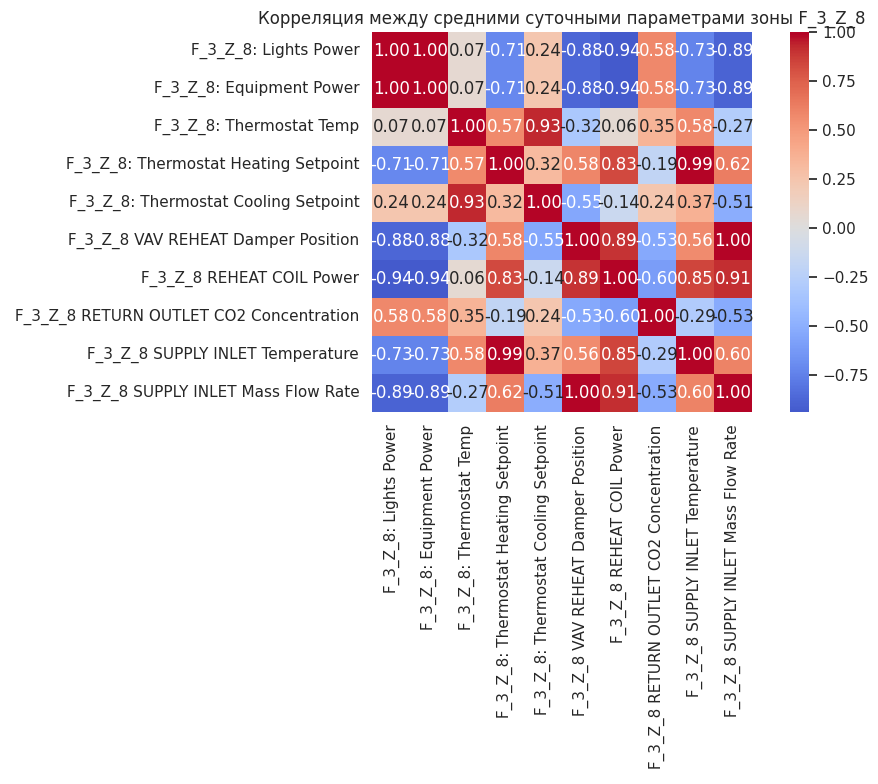

In [20]:
corr = daily_mean.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Корреляция между средними суточными параметрами зоны F_3_Z_8")
plt.tight_layout()
plt.show()

In [21]:
## Выводы по матрицы корреляции
## Матрица корреляций показывает несколько почти дублирующихся пар:
##    - Lights Power и Equipment Power
##        - Их поведение практически совпадает, поэтому для лица Чернова достаточно оставить только один из этих признаков.
##    - VAV REHEAT Damper Position и SUPPLY INLET Mass Flow Rate
##        - Между ними также наблюдается почти идеальная связь, поэтому для лица Чернова достаточно оставить только один из этих признаков.

In [22]:
selected_cols = [
    " F_3_Z_8: Lights Power",
    " F_3_Z_8: Thermostat Temp",
    " F_3_Z_8: Thermostat Heating Setpoint",
    " F_3_Z_8: Thermostat Cooling Setpoint",
    " F_3_Z_8 REHEAT COIL Power",
    " F_3_Z_8 RETURN OUTLET CO2 Concentration",
    " F_3_Z_8 SUPPLY INLET Temperature",
    " F_3_Z_8 SUPPLY INLET Mass Flow Rate",
]

daily_selected = daily_mean[selected_cols].copy()
daily_selected.columns = [c.strip() for c in daily_selected.columns]
display(daily_selected.round(2))

,F_3_Z_8: Lights Power,F_3_Z_8: Thermostat Temp,F_3_Z_8: Thermostat Heating Setpoint,F_3_Z_8: Thermostat Cooling Setpoint,F_3_Z_8 REHEAT COIL Power,F_3_Z_8 RETURN OUTLET CO2 Concentration,F_3_Z_8 SUPPLY INLET Temperature,F_3_Z_8 SUPPLY INLET Mass Flow Rate
date,,,,,,,,
2016-05-31,503.98,23.51,19.25,24.90,0.00,560.93,12.80,0.16
2016-06-01,508.15,23.57,19.25,24.90,0.00,572.22,12.80,0.17
2016-06-02,495.65,23.72,19.25,24.90,0.00,570.34,12.80,0.19
2016-06-03,474.83,23.80,20.42,24.68,1083.01,564.29,14.95,0.27
2016-06-04,0.00,24.00,24.00,24.00,4247.14,433.47,21.24,0.49
2016-06-05,0.00,24.00,24.00,24.00,4475.20,403.85,21.70,0.49
2016-06-06,524.81,23.84,21.03,24.32,1099.52,548.90,14.99,0.26
2016-06-07,524.81,24.51,21.40,24.44,232.66,933.29,15.56,0.25
2016-06-08,516.48,24.62,21.39,24.40,212.52,1098.23,14.67,0.25


In [23]:
scaler = StandardScaler()
z_values = pd.DataFrame(
    scaler.fit_transform(daily_selected),
    index=daily_selected.index,
    columns=daily_selected.columns,
)

norm_values = (z_values - z_values.min()) / (z_values.max() - z_values.min())
display(z_values.round(2))
display(norm_values.round(2))

,F_3_Z_8: Lights Power,F_3_Z_8: Thermostat Temp,F_3_Z_8: Thermostat Heating Setpoint,F_3_Z_8: Thermostat Cooling Setpoint,F_3_Z_8 REHEAT COIL Power,F_3_Z_8 RETURN OUTLET CO2 Concentration,F_3_Z_8 SUPPLY INLET Temperature,F_3_Z_8 SUPPLY INLET Mass Flow Rate
date,,,,,,,,
2016-05-31,0.64,-0.65,-1.25,0.01,-0.99,-0.19,-1.09,-1.08
2016-06-01,0.67,-0.60,-1.25,0.01,-0.99,-0.13,-1.09,-1.03
2016-06-02,0.60,-0.47,-1.25,0.01,-0.99,-0.14,-1.09,-0.89
2016-06-03,0.49,-0.40,-0.67,-0.12,-0.36,-0.18,-0.53,-0.22
2016-06-04,-2.04,-0.23,1.10,-0.53,1.49,-0.86,1.11,1.49
2016-06-05,-2.04,-0.23,1.10,-0.53,1.62,-1.01,1.22,1.49
2016-06-06,0.76,-0.37,-0.37,-0.33,-0.35,-0.26,-0.52,-0.33
2016-06-07,0.76,0.21,-0.18,-0.27,-0.85,1.75,-0.37,-0.41
2016-06-08,0.71,0.31,-0.19,-0.29,-0.86,2.61,-0.60,-0.40


,F_3_Z_8: Lights Power,F_3_Z_8: Thermostat Temp,F_3_Z_8: Thermostat Heating Setpoint,F_3_Z_8: Thermostat Cooling Setpoint,F_3_Z_8 REHEAT COIL Power,F_3_Z_8 RETURN OUTLET CO2 Concentration,F_3_Z_8 SUPPLY INLET Temperature,F_3_Z_8 SUPPLY INLET Mass Flow Rate
date,,,,,,,,
2016-05-31,0.96,0.00,0.00,0.13,0.00,0.23,0.00,0.06
2016-06-01,0.97,0.01,0.00,0.13,0.00,0.24,0.00,0.08
2016-06-02,0.94,0.04,0.00,0.13,0.00,0.24,0.00,0.12
2016-06-03,0.90,0.06,0.19,0.10,0.24,0.23,0.18,0.37
2016-06-04,0.00,0.10,0.78,0.00,0.95,0.04,0.73,1.00
2016-06-05,0.00,0.10,0.78,0.00,1.00,0.00,0.76,1.00
2016-06-06,1.00,0.07,0.29,0.05,0.25,0.21,0.19,0.33
2016-06-07,1.00,0.21,0.35,0.06,0.05,0.76,0.24,0.30
2016-06-08,0.98,0.23,0.35,0.06,0.05,1.00,0.16,0.30


In [24]:
## Вывод по нормализации
## После стандартизации все признаки становятся сопоставимыми по масштабу.
## по z-оценкам особенно хорошо выделяются
##    - 8 июня - экстремум по CO2.
##    - 9 июня - экстремум по температуре термостата, уставкам и температуре приточного воздуха.
##    - 4–5 июня и 11–12 июня - экстремумы по режимам выходного дня и нагрева.

In [25]:
## Поиск аномальных дней
## Для каждого дня возьмём среднеквадратичное значение стандартизованных признаков.
## Чем выше это значение, тем сильнее день отличается от среднего режима работы зоны.

,anomaly_score,weekday
date,,
2016-06-09,2.052,Thursday
2016-06-05,1.279,Sunday
2016-06-04,1.230,Saturday
2016-06-12,1.062,Sunday
2016-06-08,1.049,Wednesday
2016-06-11,1.033,Saturday
2016-05-31,0.849,Tuesday
2016-06-01,0.837,Wednesday
2016-06-02,0.801,Thursday


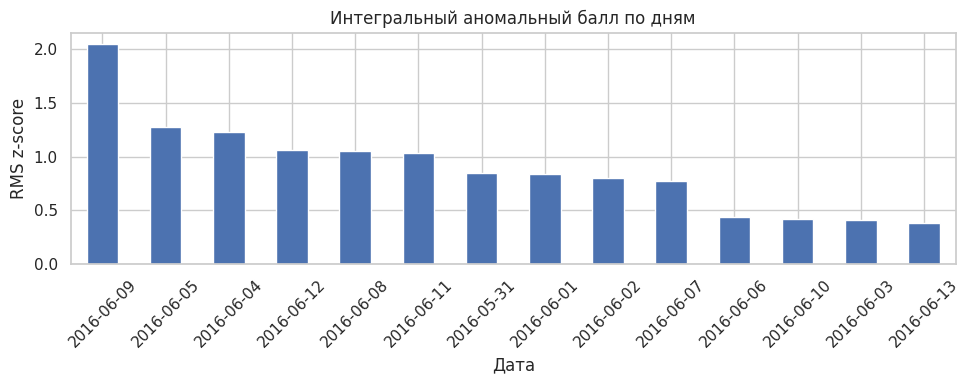

In [26]:
anomaly_score = np.sqrt((z_values ** 2).mean(axis=1))
anomaly_table = pd.DataFrame({"anomaly_score": anomaly_score,"weekday": pd.to_datetime(pd.Index(z_values.index)).day_name()}).sort_values("anomaly_score", ascending=False)

display(anomaly_table.round(3))

plt.figure(figsize=(10, 4))
anomaly_score.sort_values(ascending=False).plot(kind="bar")
plt.title("Интегральный аномальный балл по дням")
plt.ylabel("RMS z-score")
plt.xlabel("Дата")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
## Вывод по блоку аномалий
##    - 09.06.2016 — самый сильный выброс.
##    - 04.06.2016 и 05.06.2016 — так же большой выброс.
##    - 11.06.2016, 12.06.2016, 8.06.2016  — не такие большие выбросы как в днях в пунктах выше, но всеравно ярко-выраженные выбросы.
## Как можно видеть наши предположения об аномальных днях ранее полностью подтвердились.

In [28]:
def blend_color(v, cold="#c6dbef", normal="#f7f7f7", hot="#fb9a99"):
    cmap = mcolors.LinearSegmentedColormap.from_list("face_temp", [cold, normal, hot])
    return cmap(float(v))

def draw_chernoff_face(ax, row, title=None):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    lights = row["F_3_Z_8: Lights Power"]
    tstat = row["F_3_Z_8: Thermostat Temp"]
    heat_sp = row["F_3_Z_8: Thermostat Heating Setpoint"]
    cool_sp = row["F_3_Z_8: Thermostat Cooling Setpoint"]
    reheat = row["F_3_Z_8 REHEAT COIL Power"]
    co2 = row["F_3_Z_8 RETURN OUTLET CO2 Concentration"]
    supply_t = row["F_3_Z_8 SUPPLY INLET Temperature"]
    flow = row["F_3_Z_8 SUPPLY INLET Mass Flow Rate"]

    face_color = blend_color(tstat)
    ear_h = 0.10 + 0.18 * lights
    ear_w = 0.07 + 0.05 * lights
    eye_w = 0.12 + 0.10 * co2
    eye_h = 0.05 + 0.06 * co2
    pupil_r = 0.010 + 0.020 * flow
    brow_left_angle = -35 + 70 * heat_sp
    brow_right_angle = 35 - 70 * cool_sp
    nose_h = 0.10 + 0.12 * reheat
    mouth_curve = -0.12 + 0.24 * (1 - supply_t)

    left_ear = Ellipse((0.20, 0.50), ear_w, ear_h, facecolor=face_color, edgecolor="black", linewidth=1.0, zorder=0)
    right_ear = Ellipse((0.80, 0.50), ear_w, ear_h, facecolor=face_color, edgecolor="black", linewidth=1.0, zorder=0)
    ax.add_patch(left_ear)
    ax.add_patch(right_ear)

    face = Circle((0.5, 0.50), 0.30, facecolor=face_color, edgecolor="black", linewidth=1.2, zorder=1)
    ax.add_patch(face)

    left_eye = Ellipse((0.39, 0.56), eye_w, eye_h, facecolor="white", edgecolor="black", linewidth=1.0, zorder=2)
    right_eye = Ellipse((0.61, 0.56), eye_w, eye_h, facecolor="white", edgecolor="black", linewidth=1.0, zorder=2)
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    ax.add_patch(Circle((0.39, 0.56), pupil_r, color="black", zorder=3))
    ax.add_patch(Circle((0.61, 0.56), pupil_r, color="black", zorder=3))

    def brow(center_x, center_y, angle_deg):
        length = 0.14
        angle = np.deg2rad(angle_deg)
        dx = 0.5 * length * np.cos(angle)
        dy = 0.5 * length * np.sin(angle)
        ax.plot([center_x - dx, center_x + dx], [center_y - dy, center_y + dy], color="black", linewidth=2.3, zorder=3)

    brow(0.39, 0.66, brow_left_angle)
    brow(0.61, 0.66, brow_right_angle)

    nose = Polygon([[0.50, 0.52], [0.46, 0.52 - nose_h], [0.54, 0.52 - nose_h]], closed=True, facecolor="#f2c9a5", edgecolor="#6b4e3d", linewidth=1.0, zorder=2)
    ax.add_patch(nose)

    arc_h = 0.10 + abs(mouth_curve) * 0.45
    if mouth_curve >= 0:
        mouth = Arc((0.5, 0.32), 0.20, arc_h, theta1=200, theta2=340, linewidth=2.0, color="#7f1d1d", zorder=3)
    else:
        mouth = Arc((0.5, 0.25), 0.20, arc_h, theta1=20, theta2=160, linewidth=2.0, color="#7f1d1d", zorder=3)
    ax.add_patch(mouth)

    if title:
        ax.set_title(title, fontsize=11, pad=8)

In [29]:
## Дизайн лица чернова
##    - Thermostat Temp - цвет лица, так как температура помещения — естественный эмоциональный параметр
##    - RETURN OUTLET CO2 Concentration - размер глаз, так как высокий CO2 должен бросаться в глаза
##    - Heating Setpoint - наклон левой брови, так как управляющее воздействие HVAC, хорошо видно на лице
##    - Cooling Setpoint - наклон правой брови, так как в паре с левой бровью показывает стратегию регулирования
##    - REHEAT COIL Power - размер носа, так как мощность нагрева — отдельный заметный элемент
##    - SUPPLY INLET Temperature - кривизна рта, так как высокая температура приточного воздуха делает лицо менее довольным
##    - SUPPLY INLET Mass Flow Rate - размер зрачков, так как расход воздуха — тонкая, но важная вещь
##    - Lights Power - размер ушей, так как индекатор рабочего режима зоны.
##Такое кодирование позволяет разделить:
##    - управляющие настройки HVAC - брови, нос.
##    - состояние среды - цвет лица, глаза, рот.
##    - режим использования помещения - размер ушей, размер зрачков

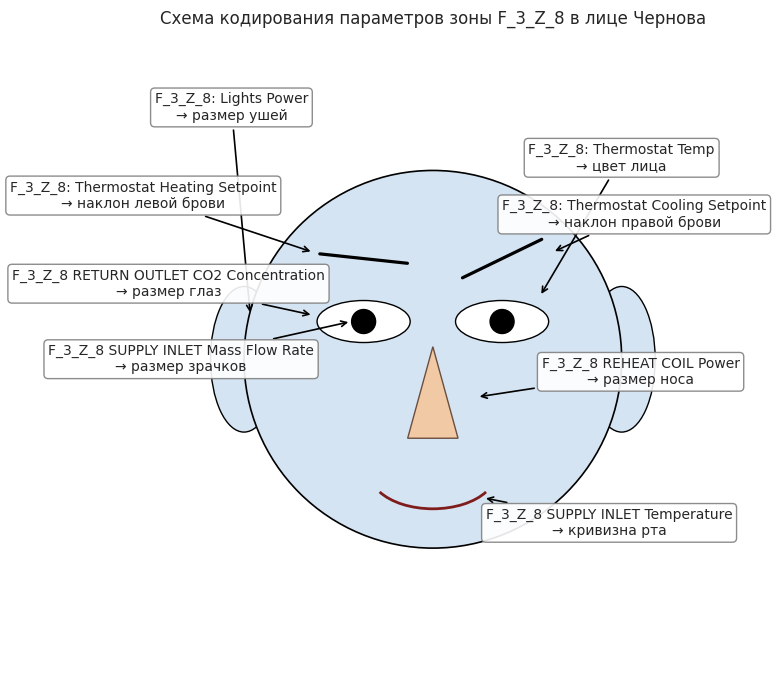

In [76]:
def draw_scheme_figure():
    fig, ax = plt.subplots(figsize=(9, 7))
    sample = norm_values.mean()
    draw_chernoff_face(ax, sample)

    annotations = [
        ("F_3_Z_8: Lights Power\n→ размер ушей", (0.18, 0.90), (0.21, 0.57)),
        ("F_3_Z_8: Thermostat Temp\n→ цвет лица", (0.80, 0.82), (0.67, 0.60)),
        ("F_3_Z_8 RETURN OUTLET CO2 Concentration\n→ размер глаз", (0.08, 0.62), (0.31, 0.57)),
        ("F_3_Z_8 SUPPLY INLET Mass Flow Rate\n→ размер зрачков", (0.10, 0.50), (0.37, 0.56)),
        ("F_3_Z_8: Thermostat Heating Setpoint\n→ наклон левой брови", (0.04, 0.76), (0.31, 0.67)),
        ("F_3_Z_8: Thermostat Cooling Setpoint\n→ наклон правой брови", (0.82, 0.73), (0.69, 0.67)),
        ("F_3_Z_8 REHEAT COIL Power\n→ размер носа", (0.83, 0.48), (0.57, 0.44)),
        ("F_3_Z_8 SUPPLY INLET Temperature\n→ кривизна рта", (0.78, 0.24), (0.58, 0.28)),
    ]

    for text, text_xy, arrow_xy in annotations:
        ax.annotate(
            text,
            xy=arrow_xy,
            xytext=text_xy,
            fontsize=10,
            arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
        )
    ax.set_title("Схема кодирования параметров зоны F_3_Z_8 в лице Чернова", pad=15)
    plt.tight_layout()
    return fig

scheme_fig = draw_scheme_figure()
plt.show()

In [77]:
## как можно видеть такой дизайн помогает быстро отличать:
##    - рабочие и выходные режимы.
##    - дни с перегревом.
##    - дни с ухудшенным воздухообменом.
##   -  дни с необычной стратегией управления HVAC.

In [78]:
## Теперь построим календарную сетку из лиц Чернова

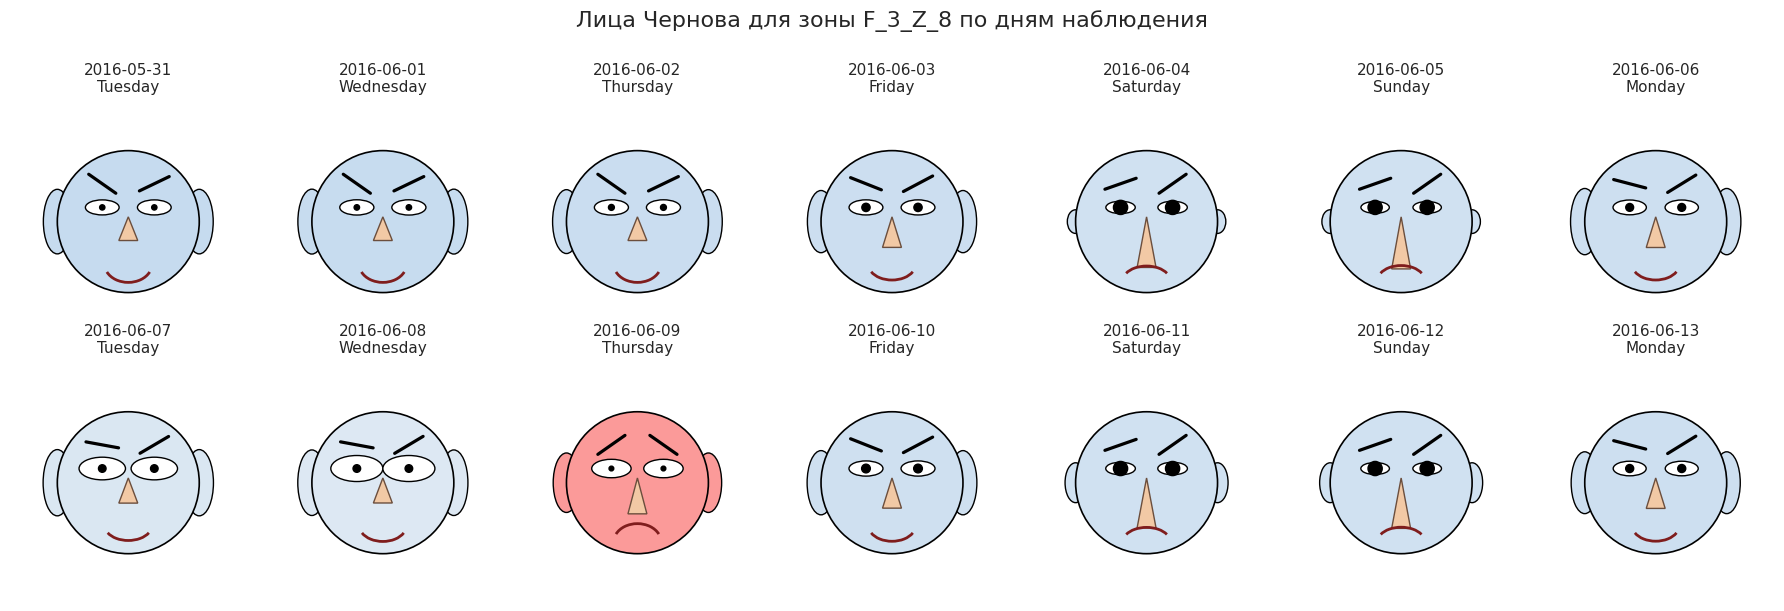

In [79]:
dates_sorted = list(norm_values.index)

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes = axes.ravel()

for ax, current_date in zip(axes, dates_sorted):
    row = norm_values.loc[current_date]
    weekday = pd.to_datetime(str(current_date)).day_name()
    title = f"{current_date}\n{weekday}"
    draw_chernoff_face(ax, row, title=title)

for ax in axes[len(dates_sorted):]:
    ax.axis("off")

fig.suptitle("Лица Чернова для зоны F_3_Z_8 по дням наблюдения", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [80]:
## Интерпретация полученной визуализации
## По календарной сетке можно сделать содержательные выводы:
## 
## Выходные режимы легко распознаются визуально
##     - 4–5 июня и 11–12 июня выглядят иначе почти по всем чертам:
##         - уши меньше из-за снижения нагрузки.
##         - лицо и рот смещаются к другому режиму.
##         - нос становится крупнее из-за роста REHEAT COIL Power.
##         - глаза и зрачки меняются из-за другога редима работы вентиляционного режима.
## 
## Это подтверждает, что пиктограмма действительно улавливает тип дня.
## 
## 8 июня — день с самой напряжённой зоной по воздуху.
##     - У этого дня особенно выделяются глаза, потому что именно 8 июня наблюдается максимум по RETURN OUTLET CO2 Concentration.  
##     - С точки зрения эксплуатации это похоже на проблему с воздухообменом, повышенную загрузку зоны или плохую настройку вентиляции.
## 
## 9 июня — наиболее аномальный рабочий день
##     - У 9 июня сильнее всего меняются сразу несколько элементов:
##         - цвет лица.
##         - наклон бровей.
##         - размер носа.
##         - форма рта.
##     - Это означает одновременное изменение:
##         - температуры зоны.
##         - нагревательной уставки.
##         - охлаждающей уставки.
##         - температуры приточного воздуха.
##         - мощности reheat coil.
## Именно поэтому 9 июня имеет наибольший интегральный аномальный балл.
## 
## 7–8 июня и 9 июня образуют цепочку подозрительных рабочих дней
##     - Визуально видно, что это не просто случайные колебания одного параметра, а серия дней, в которых меняются разные стороны работы HVAC:
##         - сначала накапливается проблема с CO2,
##         - затем возникает сильное отклонение по температурному и управляющему режиму.

In [50]:
## Ответы на ключевые вопросы.
##
## 1) В какие дни возникали аномальные ситуации?
##    - 09.06.2016 — наиболее выраженная аномалия;
##    - 08.06.2016 — аномалия качества воздуха (максимальный CO2);
##    - 07.06.2016 — преданомальный рабочий день, уже заметно отклоняющийся от нормы;
##    - 04–05.06.2016 и 11–12.06.2016 — сильно отличающиеся выходные режимы.
##
## 2) Какие параметры связаны с аномалиями?
##    - RETURN OUTLET CO2 Concentration — индикатор ухудшения воздухообмена и загруженности зоны.  
##    - Thermostat Temp — отражает фактическое состояние помещения.
##    - Thermostat Heating Setpoint и Thermostat Cooling Setpoint — показывают изменение логики управления.
##    - SUPPLY INLET Temperature — связан с температурным режимом подачи воздуха.
##    - REHEAT COIL Power — показывает интенсивность догрева воздуха.
##    - SUPPLY INLET Mass Flow Rate — характеризует объём приточного воздуха.
##    - Lights Power— помогает отличить рабочие дни от выходных и интерпретировать остальное поведение.